In [1]:
!pip install --upgrade seaborn
!pip install plotly

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.0
    Uninstalling seaborn-0.12.0:
      Successfully uninstalled seaborn-0.12.0
  Using cached plotly-6.3.0-py3-none-any.whl (9.8 MB)
  Using cached narwhals-2.1.2-py3-none-any.whl (392 kB)


In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

## Inspect and clean dataset

In [3]:
charge_data = pd.read_csv('./Generated_data/EV_generated_data.csv')
charge_data = charge_data[charge_data['event'] == 1]

In [4]:
# Remove duplicates
charge_data = charge_data.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data)}")

charge_data['discharge'] = charge_data['soc'] - charge_data['end_soc']


print("\n🔋 Statistics on discharge:\n", charge_data['discharge'].describe())

Number of rows after removing duplicates: 5859
📊 Statistics on driven km:
 count    5859.000000
mean     -261.399925
std       363.232417
min     -2403.285208
25%      -440.384797
50%      -232.572373
75%       -29.116158
max       879.232122
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    5859.000000
mean      -12.613429
std         8.209891
min       -51.536449
25%       -14.768795
50%       -11.114935
75%        -7.908017
max         9.457086
Name: discharge, dtype: float64


In [5]:
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Rows with missing values:\n")

rows_with_nan = charge_data[charge_data.isna().any(axis=1)]

rows_with_nan.head(len(rows_with_nan))

| Features | NaN-counter |
odo                 0
end_odo             0
soc                 0
end_soc             0
event               0
charge_mode         0
duration_minutes    0
km_driven           0
discharge           0
dtype: int64
|----------|-------------|

🔍 Rows with missing values:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge


In [56]:
anomalous_rows_time = charge_data[(charge_data['charge_mode'] == 0)]
print(f"Number of anomalous rows: {anomalous_rows_time.shape[0]}")
print("Anomalous rows:")
print(anomalous_rows_time.head(len(anomalous_rows_time)))

charge_data = charge_data[~(charge_data['charge_mode'] == 0)].reset_index(drop=True)

Number of anomalous rows: 410
Anomalous rows:
               odo       end_odo        soc    end_soc  event  charge_mode  \
27    16818.576782  15267.216445  46.036925  55.305700      1            0   
34    10269.760487   9321.765753  78.909215  84.981128      1            0   
59     8366.609893   7113.120535  57.491179  63.730969      1            0   
86     9686.805775   8906.436346  63.847684  76.120051      1            0   
87     9021.510496   8226.705323  64.264492  75.919934      1            0   
...            ...           ...        ...        ...    ...          ...   
5642   7717.142962   6786.140158  76.207624  82.957894      1            0   
5647   8035.330990   7604.018976  58.890592  67.726493      1            0   
5651  14877.139504  14746.576757  68.628569  73.172587      1            0   
5653  15459.331958  14734.063933  37.887937  49.355776      1            0   
5681   6780.617778   6191.644265  61.630893  73.065101      1            0   

      duration_mi

In [60]:
useless_rows_charge = charge_data[(charge_data['duration_minutes'] == 0)]
print(f"Number of useless rows: {useless_rows_charge.shape[0]}")
useless_rows_charge.head(len(useless_rows_charge))

Number of useless rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min


In [61]:
charge_data = charge_data.drop(useless_rows_charge.index).reset_index(drop=True)

In [62]:
useless_rows_charge = charge_data[(charge_data['soc'] == charge_data['end_soc']) & (charge_data['end_odo'] == charge_data['odo']) & (charge_data['duration_minutes'] == 0)]
print(f"Number of useless rows: {useless_rows_charge.shape[0]}")
useless_rows_charge.head(len(useless_rows_charge))

Number of useless rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min


In [63]:
charge_data = charge_data.drop(useless_rows_charge.index)
charge_data = charge_data.reset_index(drop=True)

In [64]:
useless_rows_charge = charge_data[(charge_data['soc'] == charge_data['end_soc']) & (charge_data['duration_minutes'] > 0)]
print(f"Number of useless rows: {useless_rows_charge.shape[0]}")
useless_rows_charge.head(len(useless_rows_charge))

Number of useless rows: 0


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min


In [65]:
charge_data = charge_data.drop(useless_rows_charge.index)
charge_data = charge_data.reset_index(drop=True)

In [15]:
# statistics of the dataset for odo, end_odo, soc, end_soc
print("Statistics of the dataset:")
charge_data[['odo', 'end_odo', 'soc', 'end_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
odo,5859.0,11674.070825,4099.879290,2909.810542,8785.707640,11374.141997,14309.652983,23408.659558
end_odo,5859.0,11412.670900,4121.030888,2917.941463,8527.917760,11007.184075,14000.233777,23318.939300
soc,5859.0,59.341993,10.477854,19.045550,53.383899,60.699335,66.613109,83.589816
end_soc,5859.0,71.955422,8.671809,27.820940,67.124106,73.338774,78.106930,89.586725


In [16]:
anomalous_rows_time = charge_data[(charge_data['duration_minutes'] <= 0)]
print(f"Number of anomalous rows: {anomalous_rows_time.shape[0]}")
print("Anomalous rows:")
print(anomalous_rows_time.head(len(anomalous_rows_time)))

charge_data = charge_data[~(charge_data['duration_minutes'] < 0)].reset_index(drop=True)

Number of anomalous rows: 0
Anomalous rows:
Empty DataFrame
Columns: [odo, end_odo, soc, end_soc, event, charge_mode, duration_minutes, km_driven, discharge]
Index: []


In [17]:
useless_rows_charge = charge_data[ (charge_data['soc'] == charge_data['end_soc']) & (charge_data['end_odo'] == charge_data['odo']) & (charge_data['duration_minutes'] > 0)]
print(f"Number of anomalous rows: {useless_rows_charge.shape[0]}")

Number of anomalous rows: 0


In [19]:
anomalous_rows_charge = charge_data[(charge_data['end_soc'] < charge_data['soc'])].copy()
anomalous_rows_charge['km_driven'] = anomalous_rows_charge['end_odo'] - anomalous_rows_charge['odo']
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 54


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge
263,10206.027017,8461.495784,53.303166,52.984425,1,1,196.955108,-1744.531232,0.318741
406,21435.276657,21748.800794,56.811138,56.150544,1,1,81.924188,313.524137,0.660594
907,18308.774298,18314.441805,30.367444,29.960254,1,1,20.565518,5.667506,0.407190
1019,17114.076133,17032.268605,43.622017,41.302247,1,1,73.346933,-81.807528,2.319770
1051,20763.330754,21348.490237,45.233326,45.196255,1,1,76.478310,585.159482,0.037070
1479,12457.918560,11982.432418,45.744354,45.025225,1,1,89.627524,-475.486142,0.719129
1604,10353.497087,8985.852587,50.227057,46.779672,1,0,166.474441,-1367.644499,3.447385
1775,16793.014158,17153.867384,52.223038,51.758900,1,1,46.610305,360.853226,0.464138
1884,12225.665365,10499.107784,48.149424,44.286680,1,1,240.283323,-1726.557581,3.862744
1955,10964.530209,10715.915553,52.040100,50.567229,1,1,48.370469,-248.614655,1.472871


In [21]:
#if it increase more than 1% delete the row from data 
inital_length = len(charge_data)
element = charge_data[((charge_data['end_soc'] - charge_data['soc']) < 0)]
charge_data = charge_data[~(((charge_data['end_soc'] - charge_data['soc']) < 0))].reset_index(drop=True)
print(f"Element removed from the dataset where event = 'charge' and end_soc < soc")

final_length = len(charge_data)
print(f"Number of rows removed: {inital_length - final_length}")

Element removed from the dataset where event = 'charge' and end_soc - soc < 0%
Number of rows removed: 0


In [22]:
'''
NOT TO RUN FOR THE MOMENT

anomalous_rows_charge = charge_data[(charge_data['end_odo'] != charge_data['odo'])]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data = charge_data[~(charge_data['end_odo'] < charge_data['odo'])].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))'''

'anomalous_rows_charge = charge_data[(charge_data[\'end_odo\'] < charge_data[\'odo\'])]\nprint(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")\n\ncharge_data = charge_data[~(charge_data[\'end_odo\'] < charge_data[\'odo\'])].reset_index(drop=True)\nanomalous_rows_charge.head(len(anomalous_rows_charge ))'

In [23]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5805 entries, 0 to 5804
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   odo               5805 non-null   float64
 1   end_odo           5805 non-null   float64
 2   soc               5805 non-null   float64
 3   end_soc           5805 non-null   float64
 4   event             5805 non-null   int64  
 5   charge_mode       5805 non-null   int64  
 6   duration_minutes  5805 non-null   float64
 7   km_driven         5805 non-null   float64
 8   discharge         5805 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 408.3 KB


In [27]:
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

In [53]:
MAX_CHARGE_PER_MIN = 1.10
##########################################################



anomalous_rows_charge = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data = charge_data[~(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 103


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min
66,9924.713663,9213.621388,44.169737,81.760928,1,3,27.751434,-711.092275,-37.591191,0.738243,1.354567,1.354567
115,9556.596035,9559.331075,40.161449,81.276727,1,3,24.359556,2.735040,-41.115277,0.592470,1.687850,1.687850
127,12596.696219,12481.598545,47.421119,76.342383,1,3,22.620379,-115.097674,-28.921265,0.782137,1.278549,1.278549
197,11454.655807,10762.512581,25.752303,68.881756,1,3,27.071004,-692.143227,-43.129453,0.627669,1.593197,1.593197
201,11788.588968,12115.620398,23.797079,67.316525,1,3,20.147815,327.031430,-43.519446,0.462961,2.160008,2.160008
...,...,...,...,...,...,...,...,...,...,...,...,...
5392,15368.650483,14643.744553,32.858032,74.620047,1,3,33.631506,-724.905930,-41.762015,0.805313,1.241753,1.241753
5444,11712.823796,11135.167029,36.423096,75.275637,1,3,30.412817,-577.656767,-38.852541,0.782775,1.277505,1.277505
5496,9702.748630,10121.817256,35.586102,77.657193,1,3,17.756254,419.068627,-42.071091,0.422054,2.369368,2.369368
5497,10106.388838,10188.916311,40.703762,83.676070,1,3,21.629849,82.527473,-42.972307,0.503344,1.986713,1.986713


## Charge Analysis

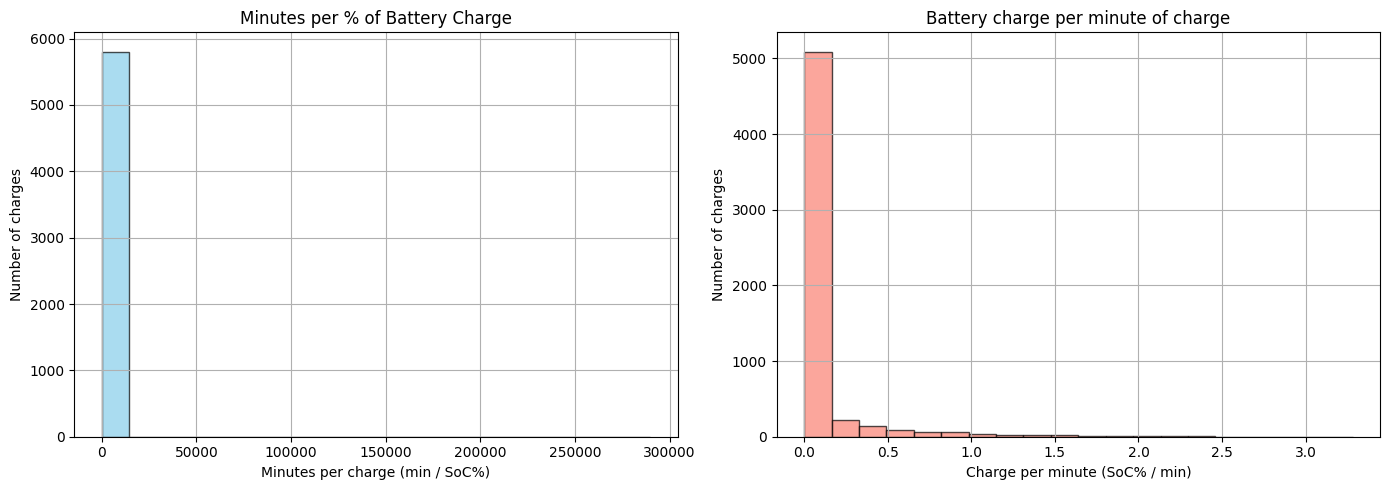

In [30]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
charge_data.head()

,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min
0,13526.135061,13011.511723,58.608544,73.716665,1,1,389.384694,-514.623338,-15.108121,25.773204,0.038800,0.038800
1,13340.668566,12261.038392,57.133040,69.782599,1,1,431.761524,-1079.630173,-12.649559,34.132535,0.029298,0.029298
2,12694.257992,12158.243453,54.626718,67.302202,1,1,612.854178,-536.014539,-12.675485,48.349566,0.020683,0.020683
3,13370.856668,13201.013401,54.987428,59.093551,1,1,183.844947,-169.843267,-4.106123,44.773365,0.022335,0.022335
4,13840.885935,13338.737646,43.717935,44.677739,1,1,167.037756,-502.148290,-0.959803,174.033292,0.005746,0.005746


In [32]:
max_min = charge_data['min_per_perc_of_battery'].max()
max_min_row = charge_data[charge_data['min_per_perc_of_battery'] == max_min]

print("\n Row with maximum min/SoC:\n")
max_min_row.head()


 Row with maximum min/SoC:



,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,min_per_perc_of_battery,discharge_per_min,charge_per_min
5322,21717.458785,22174.827721,70.86154,70.86236,1,1,237.81879,457.368935,-0.000821,289830.18573,0.000003,0.000003


In [117]:
'''outliers = charge_data[charge_data['km_per_perc_of_battery'] > 20].sort_values(by='km_per_perc_of_battery', ascending=False)
charge_data = charge_data[~(charge_data['km_per_perc_of_battery'] > 20)].reset_index(drop=True)
print(f'There are {len(outliers)} outliers')
outliers.head(len(outliers))'''

There are 109 outliers


,odo,end_odo,soc,end_soc,event,charge_mode,duration_minutes,km_driven,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
445,16303.236735,16431.523952,78.248000,78.195987,0,0,85.535438,128.287217,0.052013,89.988818,2466.437082,0.000405
146,10382.717220,10542.489434,75.759106,75.652613,0,0,82.305690,159.772214,0.106493,116.472297,1500.305539,0.000667
157,22323.939659,22407.498109,67.691483,67.582697,0,0,41.968624,83.558450,0.108787,119.458456,768.095335,0.001302
591,7222.892846,7276.398451,74.421088,74.304997,0,0,40.207631,53.505605,0.116092,79.843956,460.891133,0.002170
380,23268.628998,23303.896495,58.901773,58.818036,0,0,22.394388,35.267497,0.083737,94.490182,421.168046,0.002374
...,...,...,...,...,...,...,...,...,...,...,...,...
114,9542.316170,9640.854747,54.591137,49.871275,0,0,65.072637,98.538577,4.719862,90.857154,20.877428,0.047899
201,21495.109627,21552.141041,77.627824,74.882225,0,0,33.078561,57.031414,2.745599,103.447211,20.771938,0.048142
614,9485.331184,9602.716718,71.835655,66.166802,0,0,54.344344,117.385534,5.668853,129.601932,20.707104,0.048293
28,8452.276438,8558.427584,72.674545,67.478109,0,0,56.357376,106.151146,5.196437,113.012158,20.427680,0.048953


In [33]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5805 entries, 0 to 5804
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   odo                      5805 non-null   float64
 1   end_odo                  5805 non-null   float64
 2   soc                      5805 non-null   float64
 3   end_soc                  5805 non-null   float64
 4   event                    5805 non-null   int64  
 5   charge_mode              5805 non-null   int64  
 6   duration_minutes         5805 non-null   float64
 7   km_driven                5805 non-null   float64
 8   discharge                5805 non-null   float64
 9   min_per_perc_of_battery  5805 non-null   float64
 10  discharge_per_min        5805 non-null   float64
 11  charge_per_min           5805 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 544.3 KB


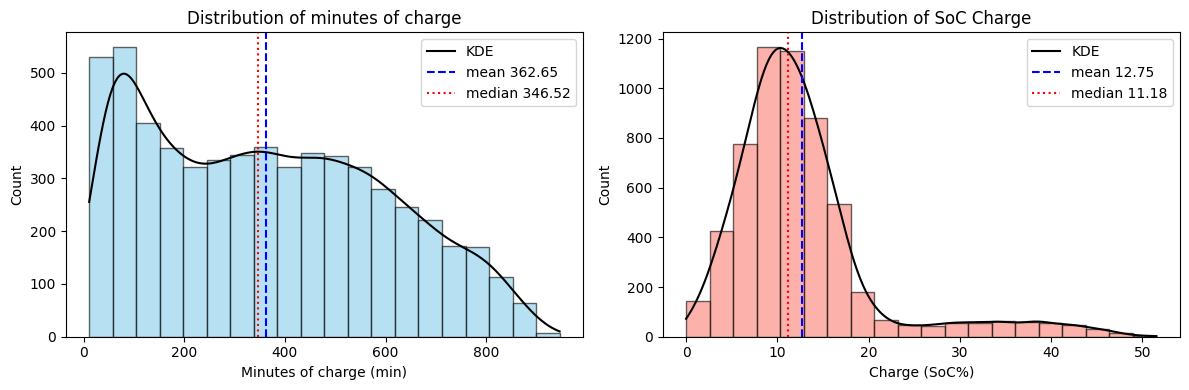

In [36]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(-charge_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Charge', xlabel='Charge (SoC%)')

plt.tight_layout()
plt.show()

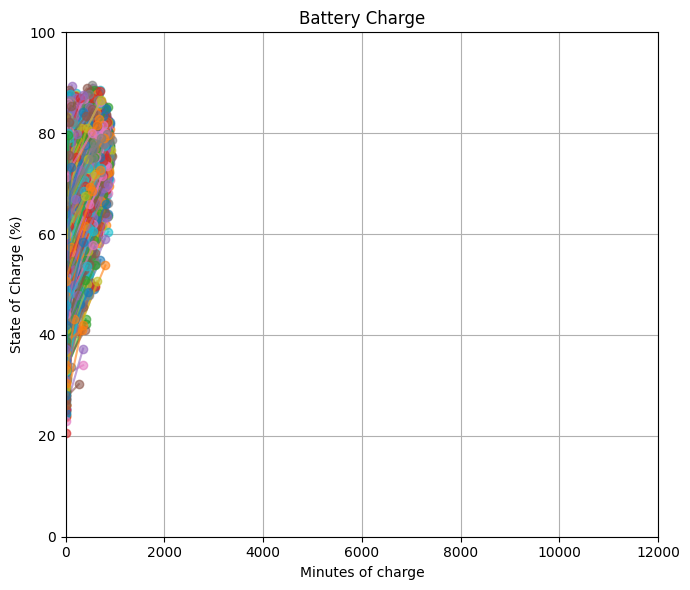

In [66]:
# Max min for x-axis scaling
max_minutes = charge_data['duration_minutes'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in charge_data.iterrows():
    x_vals = [0, row['duration_minutes']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Charge')
ax.set_xlabel('Minutes of charge')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_minutes)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(charge_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['duration_minutes']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"charge {row['index']}",
            hovertemplate=(
                f"charge index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Min of charge: {row['duration_minutes']} min<br>"
            )
        )
    )

fig.update_xaxes(title_text='Minutes of charge', range=[0, max_minutes])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Charge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [55]:
charge_data['charge_per_min'].describe()

count    5702.000000
mean        0.081387
std         0.162601
min         0.000003
25%         0.020859
50%         0.027419
75%         0.046090
max         1.095968
Name: charge_per_min, dtype: float64

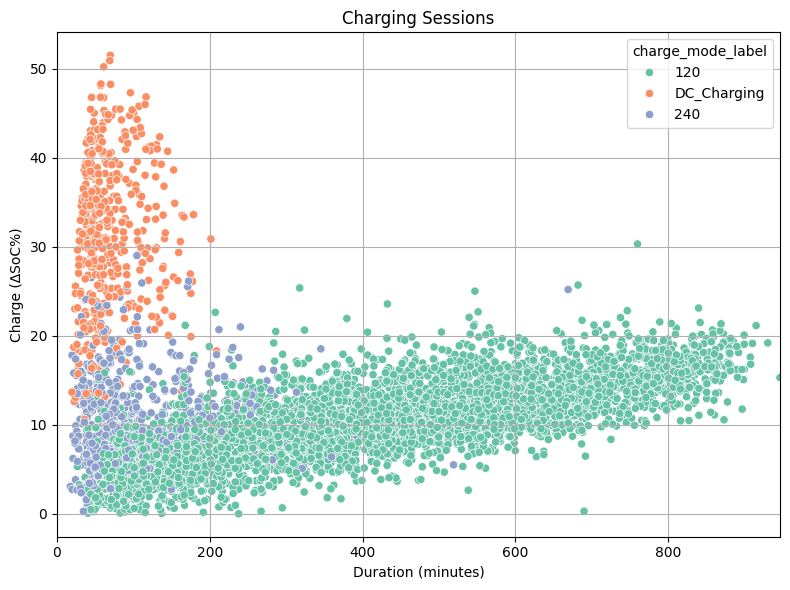

In [70]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
# Mapping of charge_mode
charge_mode_map = {
    0: "0",
    1: "120",
    2: "240",
    3: "DC_Charging"
}
charge_data = charge_data.copy()
charge_data["charge_mode_label"] = charge_data["charge_mode"].map(charge_mode_map)
charge_data['charge'] = -charge_data['discharge']

max_duration = charge_data["duration_minutes"].max()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    palette="Set2",   # use a default color palette
    legend="auto"
)

plt.title("Charging Sessions")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (∆SoC%)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Original dataset

In [39]:
charge_data_original = pd.read_csv('./datasets/EV_data.csv')
charge_data_original = charge_data_original[charge_data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          238 non-null    float64
 1   timestamp    238 non-null    object 
 2   end_time     238 non-null    object 
 3   odo          238 non-null    float64
 4   end_odo      238 non-null    float64
 5   soc          238 non-null    float64
 6   end_soc      238 non-null    float64
 7   event        238 non-null    object 
 8   charge_mode  238 non-null    object 
dtypes: float64(5), object(4)
memory usage: 16.9+ KB


In [44]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\n🔋 Statistics on Charge:\n", -charge_data_original['discharge'].describe())

Number of rows after removing duplicates: 238

🔋 Statistics on Charge:
 count   -238.000000
mean      16.743697
std      -14.980801
min       52.900000
25%       29.400000
50%       12.600000
75%        2.400000
max        0.300000
Name: discharge, dtype: float64


In [47]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)


In [49]:
MAX_CHARGE_PER_MIN = 125648
##########################################################



anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,discharge,duration_minutes,min_per_perc_of_battery,discharge_per_min,charge_per_min


In [50]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      238 non-null    float64       
 1   timestamp                238 non-null    datetime64[ns]
 2   end_time                 238 non-null    datetime64[ns]
 3   odo                      238 non-null    float64       
 4   end_odo                  238 non-null    float64       
 5   soc                      238 non-null    float64       
 6   end_soc                  238 non-null    float64       
 7   event                    238 non-null    object        
 8   charge_mode              238 non-null    object        
 9   discharge                238 non-null    float64       
 10  duration_minutes         238 non-null    float64       
 11  min_per_perc_of_battery  238 non-null    float64       
 12  discharge_per_min        238 non-nul

In [51]:
charge_data_original['charge_per_min'].describe()

count    238.000000
mean       0.329282
std        0.413422
min        0.006780
25%        0.019427
50%        0.080000
75%        0.822581
max        1.150000
Name: charge_per_min, dtype: float64